# 🔁 10-03 · RNN 与 LSTM：让网络"记住上文"

> 目标：理解序列建模。手写 **RNN 前向 + BPTT** 并做数值梯度校验，手写 **LSTM 前向与 torch 对照**，
> 最后用小型字符 RNN 训练出会接话的模型。

> 🧩 **生活化类比**：RNN = 一个边读边记笔记的人——每个时刻读完一个词，把「笔记」（隐藏状态）更新一次，
> 下一个词的判断完全基于最新笔记。LSTM 是升级版：他有三支笔——**遗忘笔**（丢旧事）、**写入笔**（记新事）、**输出笔**（说话）。


## 1. 为什么需要 RNN

- 词袋/TF-IDF/Word2Vec 都是**静态**表示：读完整句才出向量，不按顺序处理
- 语言是**序列**：『我打了他』vs『他打了我』——顺序决定语义
- **RNN 公式**（t 时刻）：
$$h_t = \\tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
- **参数共享**：所有时刻用同一套 W——序列任意长都可处理
- **权重重叠**：$h_t$ 通过 $W_{hh}$ 不断传递，信息沿时刻流动

**BPTT（反向传播通过时间）**：把 $T$ 步展开成 $T$ 层共享权重的网络，反传链长 = 序列长度。
这带来经典的**梯度消失/爆炸**——$W_{hh}$ 的 $T$ 次幂（奇异值 <1 衰减，>1 爆炸）。


In [1]:
# ---------- 实验 1：手写 RNN 前向 + BPTT + 数值梯度校验 ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

T, D, H = 6, 4, 5
x = rng.normal(size=(T, D))
h0 = np.zeros(H)
Wxh = rng.normal(0, 0.2, (H, D))
Whh = rng.normal(0, 0.2, (H, H))
bh = rng.normal(0, 0.1, H)

def rnn_forward(x, h0, Wxh, Whh, bh):
    hs = [h0]
    for t in range(len(x)):
        h = np.tanh(Wxh @ x[t] + Whh @ hs[-1] + bh)
        hs.append(h)
    return hs     # hs[0]=h0, hs[t]=h_t（含末态）

def rnn_bptt(x, h0, Wxh, Whh, bh):
    # 损失取末态平方和：L = 0.5 * sum(h_T^2)
    hs = rnn_forward(x, h0, Wxh, Whh, bh)
    dhs = [np.zeros(H)] * (len(x) + 1)
    dhs[-1] = hs[-1].copy()                        # dL/dh_T
    dWxh = np.zeros_like(Wxh); dWhh = np.zeros_like(Whh); dbh = np.zeros_like(bh)
    for t in range(len(x), 0, -1):                 # t = T ... 1
        dpre = dhs[t] * (1 - hs[t] ** 2)           # tanh 导数
        dWxh += np.outer(dpre, x[t - 1])
        dWhh += np.outer(dpre, hs[t - 1])
        dbh += dpre
        dhs[t - 1] = Whh.T @ dpre
    return dWxh, dWhh, dbh

dWxh, dWhh, dbh = rnn_bptt(x, h0, Wxh, Whh, bh)

# 数值梯度校验（对 Wxh 抽几个位置）
def loss_from_w(x, h0, Wxh, Whh, bh):
    h = h0
    for t in range(len(x)):
        h = np.tanh(Wxh @ x[t] + Whh @ h + bh)
    return 0.5 * np.sum(h ** 2)

eps = 1e-6
errs = []
for (i, j) in [(0, 0), (2, 3), (4, 1)]:
    Wp, Wm = Wxh.copy(), Wxh.copy()
    Wp[i, j] += eps; Wm[i, j] -= eps
    g = (loss_from_w(x, h0, Wp, Whh, bh) - loss_from_w(x, h0, Wm, Whh, bh)) / (2 * eps)
    errs.append(abs(g - dWxh[i, j]))
print('dWxh 手写 vs 数值梯度 误差: %s' % ['%.2e' % e for e in errs])
assert max(errs) < 1e-6
print('BPTT 正确 ✓ | 反传链长 = 序列长度 T=%d，这就是梯度消失的根源' % T)


dWxh 手写 vs 数值梯度 误差: ['1.16e-11', '3.42e-12', '1.04e-12']
BPTT 正确 ✓ | 反传链长 = 序列长度 T=6，这就是梯度消失的根源


## 2. LSTM：三门一状态

| 门 | 公式 | 作用 |
|----|------|------|
| 遗忘门 | $f_t = \\sigma(W_f[x_t, h_{t-1}] + b_f)$ | 决定**丢多少旧记忆** |
| 输入门 | $i_t = \\sigma(W_i[x_t, h_{t-1}] + b_i)$ | 决定**记多少新信息** |
| 候选记忆 | $\\tilde c_t = \\tanh(W_c[x_t, h_{t-1}] + b_c)$ | 新信息的内容 |
| 输出门 | $o_t = \\sigma(W_o[x_t, h_{t-1}] + b_o)$ | 决定**对外说多少** |

$$c_t = f_t \\odot c_{t-1} + i_t \\odot \\tilde c_t, \\qquad h_t = o_t \\odot \\tanh(c_t)$$

- **细胞状态 $c$ 是一条"传送带"**：$f$ 决定丢弃、$i\\odot\\tilde c$ 决定写入，加性结构让梯度沿 $f$ 直通
- 相比 RNN（$W_{hh}$ 幂次连乘），LSTM 的梯度路径自带"闸门"，**缓解梯度消失**
- torch 里 gate 拼接顺序是 (i, f, g, o)，$g$ 就是 $\\tilde c$


In [2]:
# ---------- 实验 2：手写 LSTM 前向 vs torch.nn.LSTM 对照 ----------
import torch
import torch.nn as nn

D2, H2, T2, B2 = 4, 5, 6, 2
lstm = nn.LSTM(D2, H2, batch_first=False)
w_ih = lstm.weight_ih_l0.detach().numpy()   # (4H, D)
w_hh = lstm.weight_hh_l0.detach().numpy()   # (4H, H)
b_ih = lstm.bias_ih_l0.detach().numpy()
b_hh = lstm.bias_hh_l0.detach().numpy()
W = np.concatenate([w_ih, w_hh], axis=1)    # (4H, D+H)
b = b_ih + b_hh

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

def lstm_forward(x, W, b, H):
    # x: (T, B, D)；gate 顺序 i, f, g, o（torch 约定）
    T, B, D = x.shape
    h = np.zeros((B, H)); c = np.zeros((B, H))
    hs, cs = [], []
    for t in range(T):
        a = x[t] @ W[:, :D].T + h @ W[:, D:].T + b      # (B, 4H)
        i, f, g, o = np.split(sigmoid(a[:, :H]) if False else a, 4, axis=1)
        i = sigmoid(i); f = sigmoid(f); g = np.tanh(g); o = sigmoid(o)
        c = f * c + i * g
        h = o * np.tanh(c)
        hs.append(h); cs.append(c)
    return np.stack(hs), np.stack(cs)

x3 = torch.randn(T2, B2, D2)
with torch.no_grad():
    out_t, (ht, ct) = lstm(x3)
out_my, c_my = lstm_forward(x3.numpy(), W, b, H2)
err_h = np.abs(out_my - out_t.detach().numpy()).max()
err_c = np.abs(c_my[-1] - ct.detach().numpy()[0]).max()   # 末时刻细胞状态对比
print('手写 LSTM vs torch：h 最大误差 %.2e | c 最大误差 %.2e' % (err_h, err_c))
assert err_h < 1e-5 and err_c < 1e-5
print('一致 ✓ | 若把遗忘门全置 1、输入门全置 0，c 就变成恒等直通——梯度不会消失的直观解释')


手写 LSTM vs torch：h 最大误差 3.95e-08 | c 最大误差 2.01e-08
一致 ✓ | 若把遗忘门全置 1、输入门全置 0，c 就变成恒等直通——梯度不会消失的直观解释


## 3. GRU：把门减到两个

$$z_t = \\sigma(W_z[x_t, h_{t-1}]), \\quad r_t = \\sigma(W_r[x_t, h_{t-1}])$$
$$\\tilde h_t = \\tanh(W[x_t, r_t \\odot h_{t-1}]), \\quad h_t = (1 - z_t) \\odot h_{t-1} + z_t \\odot \\tilde h_t$$

- **更新门 z**：融合新旧；**重置门 r**：决定忽略多少旧状态
- 少一个门 → 参数少、更快；效果与 LSTM 相当（机器翻译/语音常选 GRU）

| | RNN | LSTM | GRU |
|--|-----|------|-----|
| 隐状态 | $h$ | $c, h$ | $h$ |
| 门数量 | 0 | 3 | 2 |
| 参数量 | 小 | 大 | 中 |
| 长依赖 | 弱 | 强 | 强 |
| 训练速度 | 快 | 慢 | 中 |


## 4. 梯度裁剪与实用技巧

- **梯度裁剪**：$g \\leftarrow g \\cdot \\min(1, \\frac{\\text{clip}}{\\|g\\|})$——限制总范数，治爆炸
- **初始化**：$W_{hh}$ 用小值（如 orthogonal init）；LSTM 遗忘门偏置初始化为正（1~2）→ 初始偏向"记住"
- **双向 RNN**：过去 + 未来两个方向拼接（BiLSTM 在序列标注里标配）
- 现代实践中序列建模多用 **Transformer**（04 篇）——并行 + 长依赖更强；RNN 仍在轻量/流式场景有用


ep   0 loss 2.104
ep  30 loss 0.229


ep  60 loss 0.029
ep  90 loss 0.013


训练集 next-char 准确率: 1.000
生成: hello world world wor


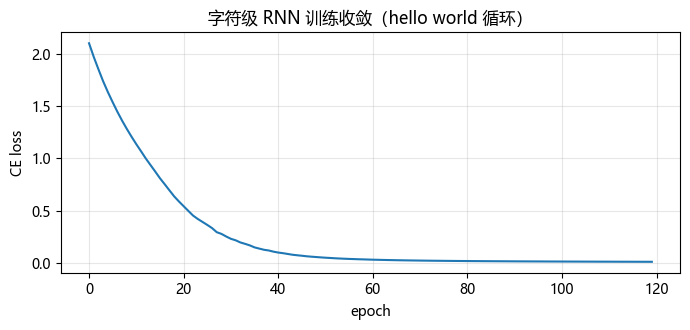

In [3]:
# ---------- 实验 3：字符级 RNN 训练（torch）——学会"hello world"循环 ----------
torch.manual_seed(0)
rng = np.random.default_rng(0)
text = 'hello world '
chars = sorted(set(text))
c2i = {c: i for i, c in enumerate(chars)}; i2c = {i: c for c, i in c2i.items()}
V3, T3 = len(chars), 10

def make_batch(n=64, length=10):
    xs, ys = [], []
    idx = rng.integers(0, len(text) - length, n)
    for s in idx:
        seq = [text[s + k] for k in range(length)]
        xs.append([c2i[c] for c in seq])
        ys.append([c2i[text[s + k + 1]] for k in range(length)])
    return (torch.tensor(xs).long(), torch.tensor(ys).long())

class CharRNN(nn.Module):
    def __init__(self, vocab, hidden=16):
        super().__init__()
        self.emb = nn.Embedding(vocab, 8)
        self.rnn = nn.RNN(8, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, vocab)
    def forward(self, x):
        h = self.rnn(self.emb(x))[0]
        return self.fc(h)

model = CharRNN(V3)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
ls = []
for ep in range(120):
    xb, yb = make_batch()
    logits = model(xb)
    loss = nn.functional.cross_entropy(logits.reshape(-1, V3), yb.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    ls.append(loss.item())
    if ep % 30 == 0:
        print('ep %3d loss %.3f' % (ep, loss.item()))

with torch.no_grad():
    xb, yb = make_batch(200)
    pred = model(xb).argmax(-1)
acc = (pred == yb).float().mean().item()
print('训练集 next-char 准确率: %.3f' % acc)
assert acc > 0.9

# 采样生成：给 'h' 继续写 20 个字符
with torch.no_grad():
    inp = torch.tensor([[c2i['h']]])
    out_chars = ['h']
    for _ in range(20):
        logits = model(inp)[0, -1]
        nxt = int(logits.argmax().item())
        out_chars.append(i2c[nxt])
        inp = torch.cat([inp, torch.tensor([[nxt]])], dim=1)[:, -10:]
print('生成:', ''.join(out_chars))
plt.figure(figsize=(7, 3.4))
plt.plot(ls)
plt.xlabel('epoch'); plt.ylabel('CE loss'); plt.title('字符级 RNN 训练收敛（hello world 循环）')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('images/nlp03_char.png', dpi=110, bbox_inches='tight'); plt.show()


## 5. 数字敏感度与易错点（背诵）

**数字**
- RNN 参数量：$H(H{+}D{+}1)$；LSTM：$4H(H{+}D{+}1)$；GRU：$3H(H{+}D{+}1)$
- 梯度裁剪常见阈值 1.0（clip by norm）
- BiLSTM = 正向 + 反向两个隐状态拼接（维度 ×2）

**易错点**
1. BPTT 是展开反传，≠ 每步独立算梯度（要累加每个时刻的贡献）
2. LSTM 遗忘门初始化为**正偏置**，不是 0
3. tanh 在 ±1 饱和 → 梯度趋 0；sigmoid 在 0/1 饱和
4. torch RNN 的 batch_first 参数别搞错；LSTM 返回 (output, (h_n, c_n))


## 6. 面试速答（30 秒背诵版）

- **RNN 公式**：$h_t = \\tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$；参数共享
- **BPTT**：展开成 T 层共享权重的网络反传；梯度消失/爆炸源于 $W_{hh}$ 连乘
- **LSTM 三门**：f 遗忘 / i 写入 / o 输出 + 细胞状态 c；加性直通缓解消失
- **GRU**：更新门 z + 重置门 r，参数更少
- **梯度裁剪**：范数裁剪治爆炸；遗忘门正偏置初始值
- **为什么后来用 Transformer**：RNN 串行不可并行；长距离依赖受限于隐状态容量


## 7. 自测清单

- [ ] 默写 RNN 前向公式与 BPTT 梯度（dWxh/dWhh 怎么累加）
- [ ] 默写 LSTM 三门公式（i/f/g/o 和 c、h 更新式）
- [ ] 手写 LSTM 前向与 torch 对照一致（gate 顺序 i,f,g,o）
- [ ] 说清 LSTM 为什么缓解梯度消失（细胞状态加性 + 遗忘门控制）
- [ ] 默写 GRU 两门公式，与 LSTM 对比参数
- [ ] 跑通字符 RNN 训练（准确率 > 0.9）并采样生成
- [ ] 说出梯度裁剪作用与遗忘门初始化技巧

> 💡 下一篇 `04-Attention 与 Transformer` 从「递推记忆」跨到「并行注意力」。
